## Эксперименты по определению оптимизатора
- Цель: установить наилучший по быстроте сходимости из трех разных подходов поиска оптимальной конфигурации модель-гиперпараметры: Optuna, SMAC, Random Search. 

В этом эксперименте важно установить наиболее быстрый подход, то есть тот, который найдет оптимальное по качеству решение быстрее, поэтому выбор меры качества мы выбрали из классических мер - мера силуэта. Кол-во итераций для каждого подхода было . Кол-во повторений для каждого датасета было 10 раз. 

При запуске через anaconda используйте официциальную страницу инсталляции: https://www.anaconda.com/docs/getting-started/anaconda/install

In [ ]:
%pip install --upgrade pip setuptools wheel
%pip install optuna smac hdbscan scikit-learn numpy matplotlib pandas pyarrow

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import (
    KMeans, Birch, BisectingKMeans, 
    DBSCAN, MeanShift
)
from hdbscan import HDBSCAN
import optuna
from ConfigSpace import (
    ConfigurationSpace, 
    Integer, Float, Categorical,
    EqualsCondition, OrConjunction
)
from smac import HyperparameterOptimizationFacade, Scenario
import time
import warnings
from ConfigSpace import AndConjunction, OrConjunction

# Игнорируем предупреждения
warnings.filterwarnings('ignore')

/home/nick/repositories/CoolPrompt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
def evaluate_model(params):
    """Функция для оценки модели кластеризации"""
    model_type = params['model']
    
    try:
        # Выбор и инициализация модели
        if model_type == 'kmeans':
            model = KMeans(
                n_clusters=params['n_clusters'],
                random_state=0,
                n_init=10
            )
        elif model_type == 'birch':
            model = Birch(
                n_clusters=params.get('n_clusters', None),
                threshold=params.get('threshold', 0.5),
            )
        elif model_type == 'bisecting_kmeans':
            model = BisectingKMeans(
                n_clusters=params['n_clusters'],
                random_state=0,
                n_init=10
            )
        elif model_type == 'hdbscan':
            model = HDBSCAN(
                min_cluster_size=params['min_cluster_size'],
                min_samples=params.get('min_samples', 5)
            )
        elif model_type == 'dbscan':
            model = DBSCAN(
                eps=params['eps'],
                min_samples=params['min_samples']
            )
        elif model_type == 'meanshift':
            model = MeanShift(
                bandwidth=params['bandwidth']
            )
        else:
            return -1
        
        # Обучение модели и получение меток
        labels = model.fit_predict(X)
        
        # Проверка валидности кластеризации
        unique_labels = np.unique(labels)
        if len(unique_labels) < 2 or (labels == -1).all():
            return -1
        
        return silhouette_score(X, labels)
    
    except Exception as e:
        return -1

# Модифицированный Random Search
def random_search(n_trials):
    best_score = -1
    best_params = None
    history = []
    
    for _ in range(n_trials):
        params = {}
        model_type = np.random.choice([
            'kmeans', 'bisecting_kmeans',
            'hdbscan', 'dbscan', 'meanshift'
        ])
        params['model'] = model_type
        
        if model_type in ['kmeans', 'birch', 'bisecting_kmeans']:
            params['n_clusters'] = np.random.randint(2, 11)
            if model_type == 'birch':
                params['threshold'] = np.random.uniform(0.1, 1.0)
                
        elif model_type == 'hdbscan':
            params['min_cluster_size'] = np.random.randint(2, 21)
            params['min_samples'] = np.random.randint(1, 21)
            
        elif model_type == 'dbscan':
            params['eps'] = np.random.uniform(0.1, 2.0)
            params['min_samples'] = np.random.randint(2, 21)
            
        elif model_type == 'meanshift':
            params['bandwidth'] = np.random.uniform(0.1, 2.0)
            
        score = evaluate_model(params)
        history.append(score)
        if score > best_score:
            best_score = score
            best_params = params

    return best_score, best_params, history  # Добавляем возврат истории

# Модифицированная функция для Optuna
def optuna_objective(trial):
    global optuna_history
    params = {}
    model_type = trial.suggest_categorical('model', [
        'kmeans', 'birch', 'bisecting_kmeans',
        'hdbscan', 'dbscan', 'meanshift'
    ])
    params['model'] = model_type
    
    if model_type in ['kmeans', 'birch', 'bisecting_kmeans']:
        params['n_clusters'] = trial.suggest_int('n_clusters', 2, 10)
        if model_type == 'birch':
            params['threshold'] = trial.suggest_float('threshold', 0.1, 1.0)
            
    elif model_type == 'hdbscan':
        params['min_cluster_size'] = trial.suggest_int('min_cluster_size', 2, 20)
        params['min_samples'] = trial.suggest_int('min_samples', 1, 20)
        
    elif model_type == 'dbscan':
        params['eps'] = trial.suggest_float('eps', 0.1, 2.0)
        params['min_samples'] = trial.suggest_int('min_samples', 2, 20)
        
    elif model_type == 'meanshift':
        params['bandwidth'] = trial.suggest_float('bandwidth', 0.1, 2.0)
        
    score = evaluate_model(params)
    optuna_history.append(score)  # Сохраняем результат итерации
    return score

In [ ]:
n_trials = 50

optuna_history = []
smac_history = []

optuna_histories = []
smac_histories = []
random_histories = []


# Конфигурационное пространство для SMAC
def get_config_space():
    cs = ConfigurationSpace()
    model = Categorical('model', [
        'kmeans', 'birch', 'bisecting_kmeans',
        'hdbscan', 'dbscan', 'meanshift'
    ])
    cs.add(model)
    
    # Общие параметры
    n_clusters = Integer('n_clusters', (2, 10), default=2)
    threshold = Float('threshold', (0.1, 1.0), default=0.5)
    min_cluster_size = Integer('min_cluster_size', (2, 20), default=5)
    min_samples = Integer('min_samples', (1, 20), default=5)
    eps = Float('eps', (0.1, 2.0), default=0.5)
    bandwidth = Float('bandwidth', (0.1, 2.0), default=0.5)

    cs.add([
        n_clusters, threshold, 
        min_cluster_size, min_samples,
        eps, bandwidth
    ])
    
    # Условия для параметров
    condition_n_clusters = OrConjunction(
        EqualsCondition(n_clusters, model, 'kmeans'),
        EqualsCondition(n_clusters, model, 'birch'),
        EqualsCondition(n_clusters, model, 'bisecting_kmeans')
    )
    
    condition_min_samples = OrConjunction(
        EqualsCondition(min_samples, model, 'hdbscan'),
        EqualsCondition(min_samples, model, 'dbscan')
    )
    
    cs.add([
        condition_n_clusters,
        EqualsCondition(threshold, model, 'birch'),
        EqualsCondition(min_cluster_size, model, 'hdbscan'),
        condition_min_samples,
        EqualsCondition(eps, model, 'dbscan'),
        EqualsCondition(bandwidth, model, 'meanshift'),
    ])
    
    return cs

# Модифицированная функция для SMAC
def smac_objective(config, seed):
    params = config.get_dictionary()
    model_type = params['model']
    
    new_params = {'model': model_type}
    if model_type in ['kmeans', 'birch', 'bisecting_kmeans']:
        new_params['n_clusters'] = params.get('n_clusters', 2)
        if model_type == 'birch':
            new_params['threshold'] = params.get('threshold', 0.5)
    elif model_type == 'hdbscan':
        new_params['min_cluster_size'] = params.get('min_cluster_size', 5)
        new_params['min_samples'] = params.get('min_samples', 5)
    elif model_type == 'dbscan':
        new_params['eps'] = params.get('eps', 0.5)
        new_params['min_samples'] = params.get('min_samples', 5)
    elif model_type == 'meanshift':
        new_params['bandwidth'] = params.get('bandwidth', 0.5)
    
    score = evaluate_model(new_params)
    smac_history.append(score)  # Сохраняем результат итерации
    
    return 1 - score


# Запуск оптимизаций
# 10 повторений для каждого датасета
# Кол-во итераций поиска для одного запуска - 50
for n in ['Hidream_t2i_human_preference_2k', 'MagicBrush_3k']:
    for r in tqdm(range(10)):
        X = pd.read_parquet(f'../data/{n}.parquet')

        optuna_history = []
        smac_history = []
        
        print("Running Optuna...")
        start = time.time()
        study = optuna.create_study(direction='maximize')
        study.optimize(optuna_objective, n_trials=n_trials, n_jobs=4)
        optuna_time = time.time() - start
        
        print("Running SMAC...")
        cs = get_config_space()
        scenario = Scenario(cs, seed=42, output_directory=f'../data/smac_df_{n}_{r}', n_trials=n_trials, deterministic=True)
        smac = HyperparameterOptimizationFacade(scenario, smac_objective)
        start = time.time()
        incumbent = smac.optimize()
        smac_time = time.time() - start
        
        print("Running Random Search...")
        start = time.time()
        random_score, random_params, random_history = random_search(n_trials)
        random_time = time.time() - start

        optuna_histories.append(optuna_history)
        smac_histories.append(smac_history)
        random_histories.append(random_history)

    optuna_df = pd.DataFrame(optuna_histories)
    smac_df = pd.DataFrame(smac_histories)
    random_df = pd.DataFrame(random_histories)

    smac_df.to_parquet(f'../data/test_smac_df_{n}.parquet')
    optuna_df.to_parquet(f'../data/test_optuna_df_{n}.parquet')
    random_df.to_parquet(f'../data/test_random_df_{n}.parquet')

In [8]:
# Вычисляем скользящие максимумы для лучшей визуализации прогресса
def rolling_max(values):
    return [max(values[:i+1]) for i in range(len(values))]

def get_metrics_df(df):
    new_df = pd.DataFrame()
    
    new_df['mean'] = rolling_max(df.mean())
    new_df['std'] = df.std()

    new_df['ci'] = 1.96 * new_df['std'] / np.sqrt(n_trials)
    new_df['ci_lower'] = new_df['mean'] - new_df['ci']
    new_df['ci_upper'] = new_df['mean'] + new_df['ci']
    
    return new_df

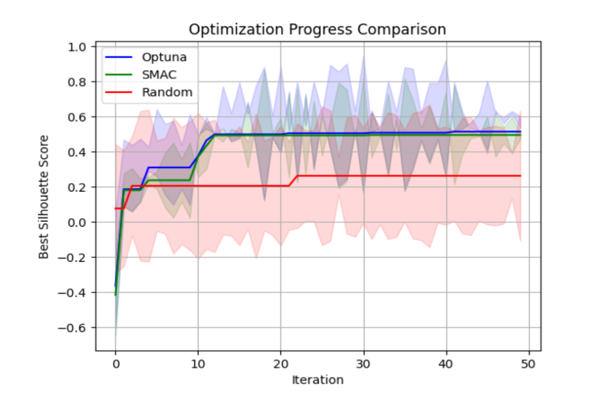

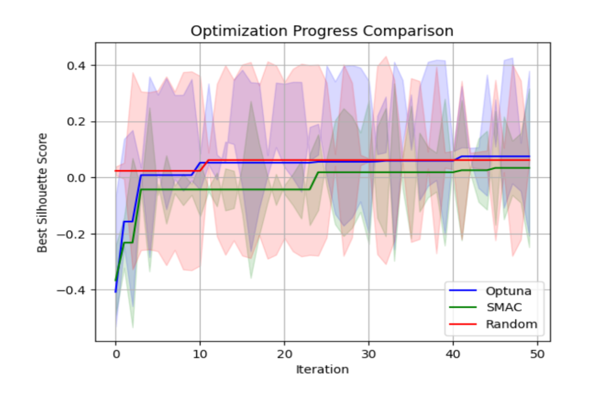

In [ ]:
# Запуск оптимизаций
for n in ['Hidream_t2i_human_preference_2k', 'MagicBrush_3k']:
    smac_df = pd.read_parquet(f'../data/test_smac_df_{n}.parquet')
    optuna_df = pd.read_parquet(f'../data/test_optuna_df_{n}.parquet')
    random_df = pd.read_parquet(f'../data/test_random_df_{n}.parquet')
    
    smac_new_df = get_metrics_df(smac_df)
    optuna_new_df = get_metrics_df(optuna_df)
    random_new_df = get_metrics_df(random_df)
    
    plt.plot(optuna_new_df['mean'], label='Optuna', color='blue')
    plt.plot(smac_new_df['mean'], label='SMAC', color='green')
    plt.plot(random_new_df['mean'], label='Random', color='red')
    plt.xlabel('Iteration')
    plt.ylabel('Best Silhouette Score')
    plt.title('Optimization Progress Comparison')
    plt.fill_between(range(n_trials), optuna_new_df['ci_lower'], optuna_new_df['ci_upper'], color='b', alpha=.15)
    plt.fill_between(range(n_trials), smac_new_df['ci_lower'], smac_new_df['ci_upper'], color='g', alpha=.15)
    plt.fill_between(range(n_trials), random_new_df['ci_lower'], random_new_df['ci_upper'], color='r', alpha=.15)
    plt.legend()
    plt.grid(True)
    plt.show()

## Выводы

На графиках в среднем Optuna быстрее достигает максимума значения по сравнению с другими методами. Как результат экспериментов было принято решение использовать этот метод в GaMAC.